# Question A1 (15 marks)

#### Design a feedforward deep neural network (DNN) which consists of **three** hidden layers of 128 neurons each with ReLU activation function, and an output layer with sigmoid activation function. Apply dropout of probability **0.3** to each of the hidden layers.

In [12]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

## Configuration for Google Colab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/SC4001 Neural Network')

from common_utils import set_seed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1.Define the model class.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

no_features = 77
no_hidden = [128, 128, 128]
no_labels = 1
dropout_rate = 0.3

batch_size = 64
learning_rate = 0.0005
weight_decay = 0.0005
max_epochs = 200
patience = 5

seed = 36

# setting seed
set_seed(seed)

In [14]:
class MLP(nn.Module):
    def __init__(self, no_features, no_hidden, no_labels, dropout_rate):
        super().__init__()

        # YOUR CODE HERE
        layers = []

        for i in range(len(no_hidden)):
            if i == 0:
                layers.append(nn.Linear(no_features, no_hidden[i]))
            else:
                layers.append(nn.Linear(no_hidden[i-1], no_hidden[i]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(no_hidden[-1], no_labels))
        layers.append(nn.Sigmoid())

        self.mlp_stack = nn.Sequential(*layers)

    # YOUR CODE HERE
    def forward(self, x):
        logits = self.mlp_stack(x)
        return logits

#### Divide the dataset into a 75:25 ratio for training and testing. Use **appropriate** scaling of input features. We solely assume that there are only two datasets here: training & test.

2.Split the dataset and do preprocessing.

In [15]:
from common_utils import split_dataset, preprocess_dataset


def preprocess(df):
    # YOUR CODE HERE
    X_train, y_train, X_test, y_test = split_dataset(
        df,
        columns_to_drop = ['filename', 'label'],
        test_size = 0.25,
        random_state = seed
    )

    X_train_scaled, X_test_scaled = preprocess_dataset(X_train, X_test)

    return X_train_scaled, y_train, X_test_scaled, y_test

df = pd.read_csv('/content/drive/MyDrive/SC4001 Neural Network/simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train_scaled, y_train, X_test_scaled, y_test = preprocess(df)

In [16]:
df['label'].value_counts()

,count
label,
1,6202
0,5855


#### Use the training dataset to train the model for 200 epochs. Use a mini-batch gradient descent with **‘Adam’** optimizer with learning rate of **0.0005**, weight decay of **0.0005** and **batch size = 64**. Implement early stopping with patience of **5**.

3.Define a Pytorch Dataset and Dataloaders.  

In [17]:
class CustomDataset(Dataset):
    # YOUR CODE HERE
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def intialise_loaders(X_train_scaled, y_train, X_test_scaled, y_test):
    # YOUR CODE HERE
    train_dataset = CustomDataset(X_train_scaled, y_train)
    test_dataset = CustomDataset(X_test_scaled, y_test)

    train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
    test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 0)

    return train_dataloader, test_dataloader


train_dataloader, test_dataloader = intialise_loaders(X_train_scaled, y_train, X_test_scaled, y_test)

4.Next, define the model, optimizer and loss function.

In [18]:
# YOUR CODE HERE
set_seed(seed)
model = MLP(no_features, no_hidden, no_labels, dropout_rate).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay = weight_decay)
loss_fn = nn.BCELoss()

In [19]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, train_correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += ((pred > 0.5) == y).type(torch.float).sum().item()

    train_loss /= num_batches
    train_correct /=size

    return train_loss, train_correct

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            test_correct += ((pred > 0.5) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    test_correct /= size

    return test_loss, test_correct

5.Train model for 200 epochs. Record down train and test accuracies. Implement early stopping.

In [20]:
# YOUR CODE HERE
from common_utils import EarlyStopper

early_stopper = EarlyStopper(patience = patience, min_delta = 0)

tr_loss, tr_correct = [], []
te_loss, te_correct = [], []
for t in range(max_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)

    tr_loss.append(train_loss), tr_correct.append(train_correct)
    te_loss.append(test_loss), te_correct.append(test_correct)


    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")

    if early_stopper.early_stop(test_loss):
        print("Done!")
        break

Epoch 1: Train_accuracy: 52.95%, Train_loss: 0.689369, Test_accuracy: 55.06%, Test_loss: 0.683908
Epoch 2: Train_accuracy: 56.64%, Train_loss: 0.678191, Test_accuracy: 57.78%, Test_loss: 0.670493
Epoch 3: Train_accuracy: 59.17%, Train_loss: 0.667718, Test_accuracy: 59.57%, Test_loss: 0.664210
Epoch 4: Train_accuracy: 60.86%, Train_loss: 0.656705, Test_accuracy: 60.40%, Test_loss: 0.656514
Epoch 5: Train_accuracy: 61.97%, Train_loss: 0.647888, Test_accuracy: 61.89%, Test_loss: 0.650855
Epoch 6: Train_accuracy: 63.19%, Train_loss: 0.640111, Test_accuracy: 62.92%, Test_loss: 0.645935
Epoch 7: Train_accuracy: 64.16%, Train_loss: 0.631263, Test_accuracy: 63.52%, Test_loss: 0.643622
Epoch 8: Train_accuracy: 64.88%, Train_loss: 0.626661, Test_accuracy: 63.78%, Test_loss: 0.635447
Epoch 9: Train_accuracy: 66.19%, Train_loss: 0.610443, Test_accuracy: 63.32%, Test_loss: 0.638899
Epoch 10: Train_accuracy: 66.37%, Train_loss: 0.607209, Test_accuracy: 64.84%, Test_loss: 0.622538
Epoch 11: Train_acc

#### Plot train and test accuracies and losses on training and test data against training epochs and comment on the line plots.


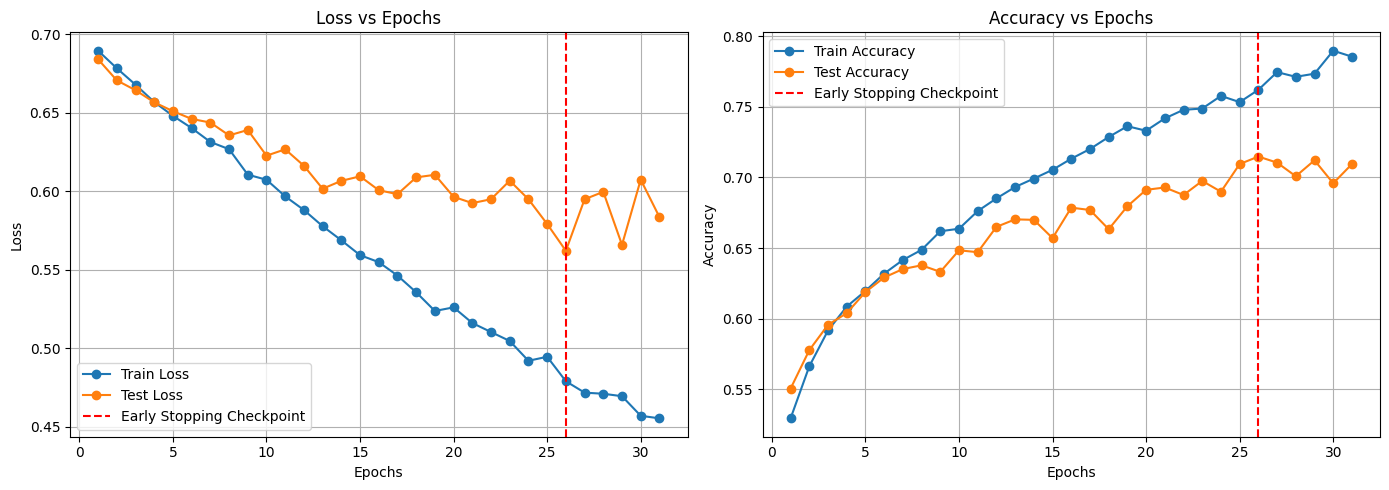

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

# Train & Test Loss
axs[0].plot(range(1, len(tr_loss)+1), tr_loss, label='Train Loss', marker='o')
axs[0].plot(range(1, len(te_loss)+1), te_loss, label='Test Loss', marker='o')
minposs = te_loss.index(min(te_loss)) + 1
axs[0].axvline(minposs, linestyle='--', color='r', label='Early Stopping Checkpoint')
axs[0].set_title('Loss vs Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Train & Test Accuracy
axs[1].plot(range(1, len(tr_correct)+1), tr_correct, label='Train Accuracy', marker='o')
axs[1].plot(range(1, len(te_correct)+1), te_correct, label='Test Accuracy', marker='o')
axs[1].axvline(minposs, linestyle='--', color='r', label='Early Stopping Checkpoint')
axs[1].set_title('Accuracy vs Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

6.Comment on line plots.

In [23]:
# YOUR CODE HERE
answer = """
Loss vs Epochs:
In the Loss vs Epochs chart, both training and test loss decrease steadily at the start. While the training loss continues to drop consistently, the test loss begins to
level off as the model starts to overfit. The test loss reaches its global minimum at epoch 26. Because the early stopping patience was set to 5, the training process
terminated at epoch 31 as no subsequent epoch achieved a lower loss than the checkpoint at epoch 26.

Accuracy vs Epochs:
Similarly, in the Accuracy vs Epochs chart, training accuracy improves linearly across all 31 epochs. However, the test accuracy peaks around epoch 26 and then begins to
fluctuate. The widening gap between the training and testing curves in both graphs confirms that the model was beginning to memorize the training data (overfitting) rather
than learning features that translate to the test set.
"""

print(answer)


Loss vs Epochs:
In the Loss vs Epochs chart, both training and test loss decrease steadily at the start. While the training loss continues to drop consistently, the test loss begins to 
level off as the model starts to overfit. The test loss reaches its global minimum at epoch 26. Because the early stopping patience was set to 5, the training process 
terminated at epoch 31 as no subsequent epoch achieved a lower loss than the checkpoint at epoch 26. 

Accuracy vs Epochs:
Similarly, in the Accuracy vs Epochs chart, training accuracy improves linearly across all 31 epochs. However, the test accuracy peaks around epoch 26 and then begins to 
fluctuate. The widening gap between the training and testing curves in both graphs confirms that the model was beginning to memorize the training data (overfitting) rather 
than learning features that translate to the test set. 

